In [1]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
from rdkit import Chem
from collections import Counter
import pandas as pd
import numpy as np
import pickle
import os

plt.rcParams['figure.dpi'] = 300

In [ ]:
# Load smiles
root = "."
df = pd.read_csv(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
df['index'] = df.index
id_to_index = dict(zip(df['id'], df['index']))
index_to_id = dict(zip(df['index'], df['id']))

# From compound ID to SMILES
synthons = {i: j for i, j in zip(df['id'], df['smiles'])}

# Dictionary with counts of each synthon
syns_counter = dict(Counter([j for i in synthons for j in i.split("____")[1:]]))
print(f"Number of unique 'synthons': {len(syns_counter)}")

Number of unique 'synthons': 1299755


In [3]:
print(f"1 occ: {len([i for i in syns_counter if syns_counter[i] == 1])}")
print(f">100 occ: {len([i for i in syns_counter if syns_counter[i] > 100])}")
print(f">1000 occ: {len([i for i in syns_counter if syns_counter[i] > 1000])}")
print(f"MAX: {max(syns_counter.values())}")

1 occ: 350697
>100 occ: 32236
>1000 occ: 2806
MAX: 22418


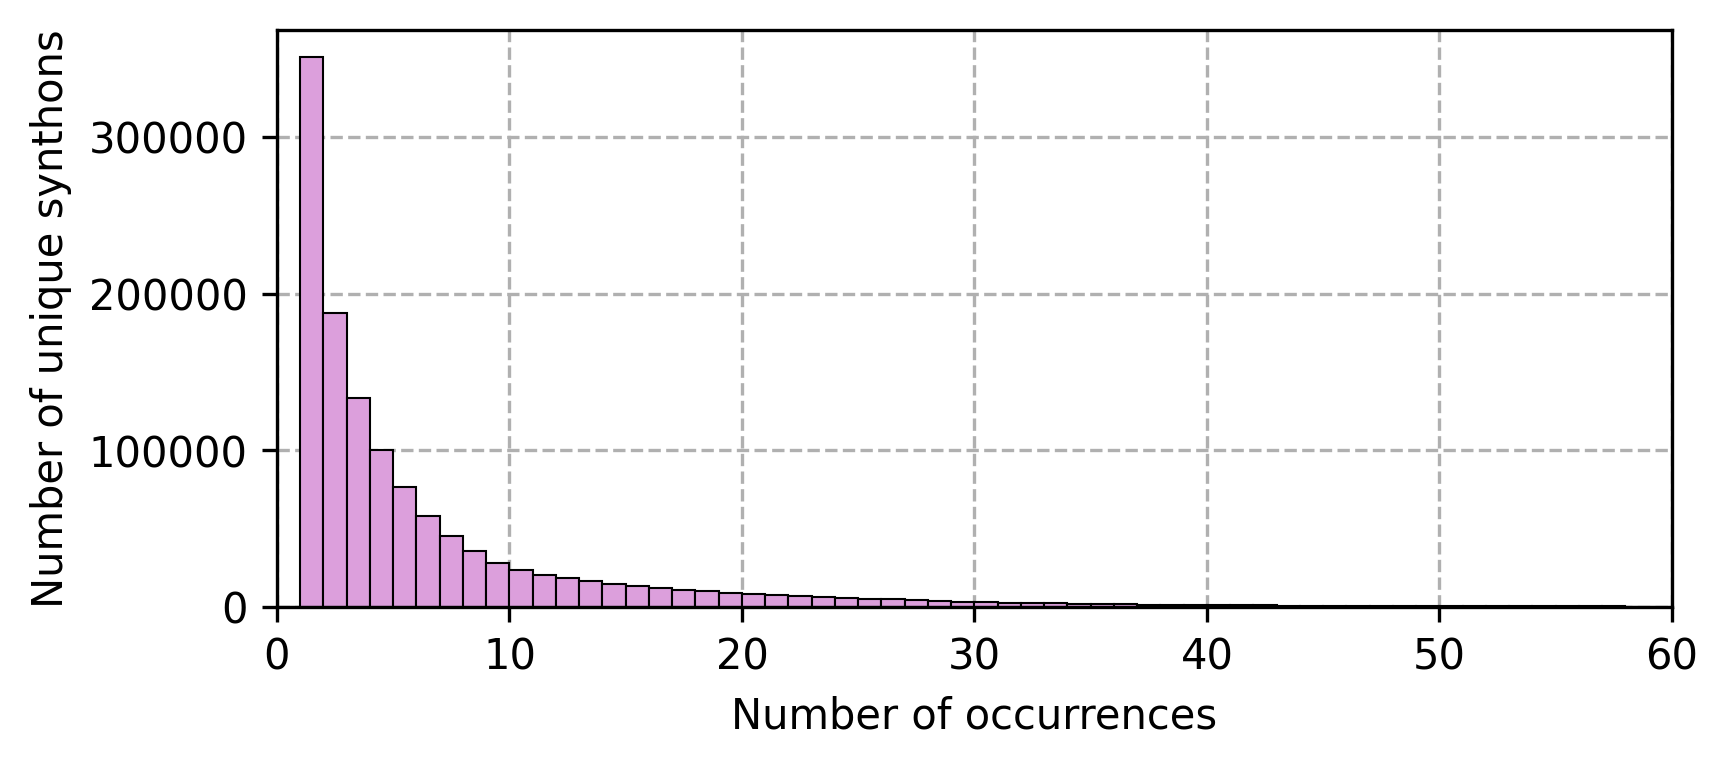

In [4]:
plt.figure(figsize=(6, 2.5))
bins = [i for i in range(0, 250, 1)]
h = [syns_counter[i] for i in syns_counter]
plt.hist(h, bins=bins, edgecolor='k', zorder=2, linewidth=0.5, color="#DC9FDC")
plt.grid(linestyle='--')
plt.xlim(0, 60)
plt.xlabel("Number of occurrences")
plt.ylabel("Number of unique synthons")
# plt.yscale('log')
plt.show()

In [5]:
[i for i in syns_counter if syns_counter[i] > 20000]

['23865182']

22418


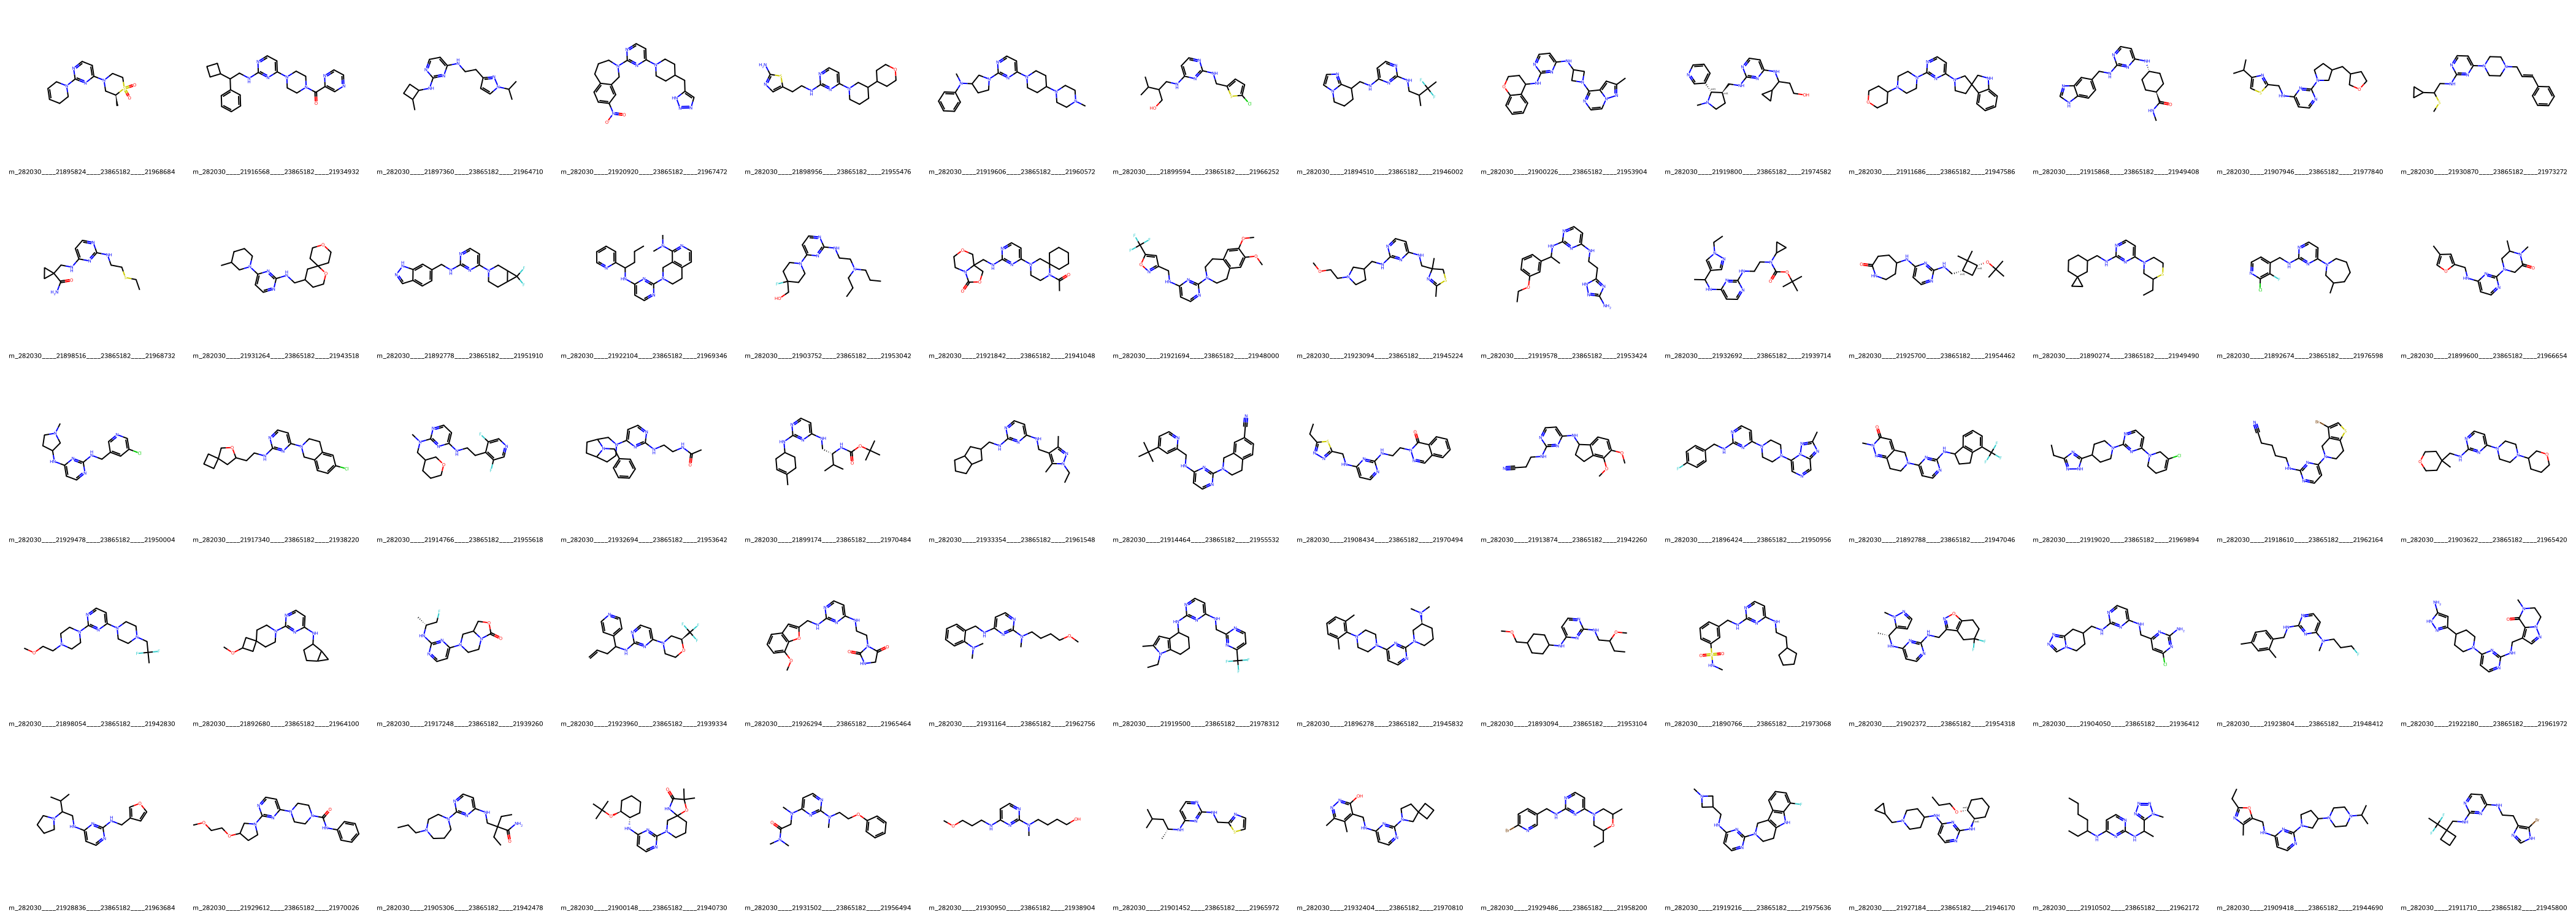

In [6]:
N = 70
s = "23865182"
print(syns_counter[s])
# Select molecules to display
DISPLAY = [i for i in synthons if s in i.split("____")][:N]
Draw.MolsToGridImage([Chem.MolFromSmiles(synthons[i]) for i in DISPLAY], legends=DISPLAY, 
                     molsPerRow=14, maxMols=N, subImgSize=(300, 300))